<a href="https://colab.research.google.com/github/MiyoBran/alura-etl-telecom-x-parte-II/blob/main/EST_TelecomX_LATAM_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge Telecom X - Parte I

##📌 Extracción

In [1]:
import pandas as pd

url='https://raw.githubusercontent.com/MiyoBran/alura-etl-telecom-x/main/TelecomX_Data.json'
df = pd.read_json(url)
display(df.head())

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
#Conociendo los datos con .info() , .shape y dtypes.
print('Usamos info()')
display(df.info())
print('Usamos shape')
display(df.shape)
print('Usamos dtypes')
display(df.dtypes.value_counts())

Usamos info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


None

Usamos shape


(7267, 6)

Usamos dtypes


,count
object,6


In [3]:
# customer phone internet account son todos diccionarios , vemos 1 registro en
# cada una usando display. para entender el contenido de los datos.
display(df['customer'][0])
display(df['phone'][0])
display(df['internet'][0])

{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'Yes',
 'tenure': 9}

{'PhoneService': 'Yes', 'MultipleLines': 'No'}

{'InternetService': 'DSL',
 'OnlineSecurity': 'No',
 'OnlineBackup': 'Yes',
 'DeviceProtection': 'No',
 'TechSupport': 'Yes',
 'StreamingTV': 'Yes',
 'StreamingMovies': 'No'}

##🔧 Transformación

En este paso, **verifica si hay problemas en los datos** que puedan afectar el análisis. Presta atención a valores ausentes, duplicados, errores de formato e inconsistencias en las categorías. Este proceso es esencial para asegurarte de que los datos estén listos para las siguientes etapas.

📌 **Tips:**

🔗 [Documentación de `pandas.unique()`](https://pandas.pydata.org/docs/reference/api/pandas.unique.html "‌")

🔗 [Documentación de `pandas.Series.dt.normalize()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.normalize.html "‌")

In [4]:
# ==============================================================================
# AUDITORÍA DE CALIDAD: Valores Únicos en la columna objetivo (Evasión)
# ==============================================================================

# Extraemos los valores únicos para detectar inconsistencias (basura en los datos)
valores_unicos_churn = df['Churn'].unique()

print("Etiquetas encontradas en la columna Churn:")
print(valores_unicos_churn)

Etiquetas encontradas en la columna Churn:
['No' 'Yes' '']


In [5]:
# ==============================================================================
# DIAGNÓSTICO DE IMPACTO: Conteo de frecuencias en la columna objetivo
# ==============================================================================

# value_counts() nos muestra la distribución exacta de cada categoría
distribucion_churn = df['Churn'].value_counts()

print("Distribución de clientes por estado de Evasión (Churn):")
print(distribucion_churn)

# También podemos aislar matemáticamente solo los espacios en blanco
cantidad_vacios = (df['Churn'] == '').sum()
print(f"\nTotal exacto de registros en blanco: {cantidad_vacios}")

Distribución de clientes por estado de Evasión (Churn):
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Total exacto de registros en blanco: 224


Ahora que has identificado las inconsistencias, es momento de aplicar las correcciones necesarias. Ajusta los datos para asegurarte de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.

📌 **Tips:**

🔗 [https://www.aluracursos.com/blog/manipulacion-de-strings-en-pandas-lower-replace-startswith-y-contains](https://www.aluracursos.com/blog/manipulacion-de-strings-en-pandas-lower-replace-startswith-y-contains "smartCard-inline")

In [6]:
import numpy as np

# ==============================================================================
# DATA CLEANING: Estandarización y Eliminación de Inconsistencias
# ==============================================================================
print(f"📦 Total de clientes ANTES de la limpieza: {df.shape[0]}")

# PASO 1 (Estandarización): Convertimos el texto vacío en un Nulo Oficial de Pandas (NaN)
# Usamos el método replace() enfocado únicamente en la columna objetivo
df['Churn'] = df['Churn'].replace('', np.nan)

# PASO 2 (Eliminación): Barrido automático de registros nulos en la columna objetivo
# El parámetro 'subset' asegura que solo mire la columna 'Churn' para decidir qué fila borrar
df = df.dropna(subset=['Churn'])

# Reiniciamos el índice numérico para que no queden "saltos" en la numeración de las filas
df = df.reset_index(drop=True)

print(f"✅ Total de clientes DESPUÉS de la limpieza: {df.shape[0]}")

📦 Total de clientes ANTES de la limpieza: 7267
✅ Total de clientes DESPUÉS de la limpieza: 7043


### Normalizacion de datos

### **Opcional:** Columna de cuentas diarias
Ahora que los datos están limpios, es momento de crear la columna **"Cuentas_Diarias"**. Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

📌 **Esta columna te ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.**

In [7]:
# ==============================================================================
# TRANSFORMACIÓN: Aplanamiento de JSON (Data Flattening) y Creación de KPIs
# ==============================================================================
print("📦 Desempaquetando contenedores de datos...")

# 1. Identificamos los "palets" (columnas que contienen diccionarios)
columnas_anidadas = ['customer', 'phone', 'internet', 'account']

# 2. Desempaquetado masivo y eficiente (List Comprehension + json_normalize)
# Extraemos todas las llaves de los diccionarios y las convertimos en columnas
df_aplanado = pd.concat(
    [pd.json_normalize(df[col]) for col in columnas_anidadas],
    axis=1
)

# 3. Consolidación del Almacén:
# Unimos la información base (ID, Churn) con los nuevos datos aplanados
# Eliminamos los contenedores originales cerrados para no duplicar memoria
df = pd.concat([df.drop(columns=columnas_anidadas), df_aplanado], axis=1)

# 4. Ingeniería de Características (Feature Engineering): Cálculo del KPI Diario
# Ahora que 'Charges.Monthly' es una columna numérica libre, podemos operarla matemáticamente
df['Cuentas_Diarias'] = round(df['Charges.Monthly'] / 30, 2)

print("\n✅ Estructura final del dataset:")
display(df.head(3))

📦 Desempaquetando contenedores de datos...

✅ Estructura final del dataset:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46


### Opcional: Estandarización y transformación de datos
La **estandarización y transformación de datos** es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más **consistente, comprensible y adecuada para el análisis**. Durante esta fase, por ejemplo, puedes convertir valores textuales como **"Sí" y "No"** en valores binarios **(1 y 0)**, lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además, **traducir o renombrar columnas y datos** hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos. Aunque no es un paso obligatorio, puede mejorar significativamente la **claridad y comunicación de los resultados**, facilitando la interpretación y evitando confusiones, especialmente al compartir información con **stakeholders no técnicos**.

In [8]:
# ==============================================================================
# ESTANDARIZACIÓN Y TRADUCCIÓN: Preparación para Machine Learning
# ==============================================================================

# 1. Diccionario de Traducción de Columnas (Mapeo de Negocio)
traduccion_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargo_Mensual',
    'Charges.Total': 'Cargo_Total'
}

# Aplicamos la traducción a las columnas
df = df.rename(columns=traduccion_columnas)

# 2. Binarización masiva para algoritmos predictivos
# Reemplazamos los 'Yes' y 'No' globales por 1 y 0 aritméticos
mapeo_binario = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}

# Aplicamos el reemplazo. El DataFrame buscará estas llaves en todas las celdas
df = df.replace(mapeo_binario)

print("✅ Traducción y Binarización completadas. Nueva estructura:")
display(df.head(3))

/tmp/ipykernel_14111/4094817821.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapeo_binario)


✅ Traducción y Binarización completadas. Nueva estructura:


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,1,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,0,0,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,1,0,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46


In [9]:
print('Usamos info()')
df.info()

Usamos info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7043 non-null   object 
 1   Evasion                  7043 non-null   int64  
 2   Genero                   7043 non-null   int64  
 3   Adulto_Mayor             7043 non-null   int64  
 4   Pareja                   7043 non-null   int64  
 5   Dependientes             7043 non-null   int64  
 6   Meses_Contrato           7043 non-null   int64  
 7   Servicio_Telefonico      7043 non-null   int64  
 8   Multiples_Lineas         7043 non-null   object 
 9   Servicio_Internet        7043 non-null   object 
 10  Seguridad_Online         7043 non-null   object 
 11  Respaldo_Online          7043 non-null   object 
 12  Proteccion_Dispositivo   7043 non-null   object 
 13  Soporte_Tecnico          7043 non-null   object 
 14  Streaming_

##📊 Carga y análisis

### Análisis Descriptivo

Para comenzar, realiza un **análisis descriptivo** de los datos, calculando métricas como **media, mediana, desviación estándar** y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

📌 **Consejos:**

🔗 [Documentación de `DataFrame.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html "‌")

In [10]:
print('Usamos describe()')
df.describe()

Usamos describe()


,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Facturacion_Electronica,Cargo_Mensual,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.495244,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2.158675
std,0.441561,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,2.990000
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,3.960000


In [11]:
# Forzamos la conversión a decimal matemático.
# errors='coerce' transformará cualquier espacio en blanco rebelde en un nulo oficial (NaN)
df['Cargo_Total'] = pd.to_numeric(df['Cargo_Total'], errors='coerce')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7043 non-null   object 
 1   Evasion                  7043 non-null   int64  
 2   Genero                   7043 non-null   int64  
 3   Adulto_Mayor             7043 non-null   int64  
 4   Pareja                   7043 non-null   int64  
 5   Dependientes             7043 non-null   int64  
 6   Meses_Contrato           7043 non-null   int64  
 7   Servicio_Telefonico      7043 non-null   int64  
 8   Multiples_Lineas         7043 non-null   object 
 9   Servicio_Internet        7043 non-null   object 
 10  Seguridad_Online         7043 non-null   object 
 11  Respaldo_Online          7043 non-null   object 
 12  Proteccion_Dispositivo   7043 non-null   object 
 13  Soporte_Tecnico          7043 non-null   object 
 14  Streaming_TV            

## Análisis de correlación entre variables

Esta actividad es un extra, por lo tanto es **OPCIONAL.**

Como un paso adicional, puedes explorar la **correlación** entre diferentes variables del dataset. Esto puede ayudar a identificar qué factores tienen **mayor relación con la evasión de clientes**, como:

🔹 La relación entre la **cuenta diaria** y la evasión.
🔹 Cómo la **cantidad de servicios contratados** afecta la probabilidad de churn.

Puedes usar la función `corr()` de Pandas para calcular las correlaciones y visualizar los resultados con **gráficos de dispersión** o **matrices de correlación**.

Este análisis adicional puede proporcionar **insights valiosos** para la creación de modelos predictivos más robustos. 🚀

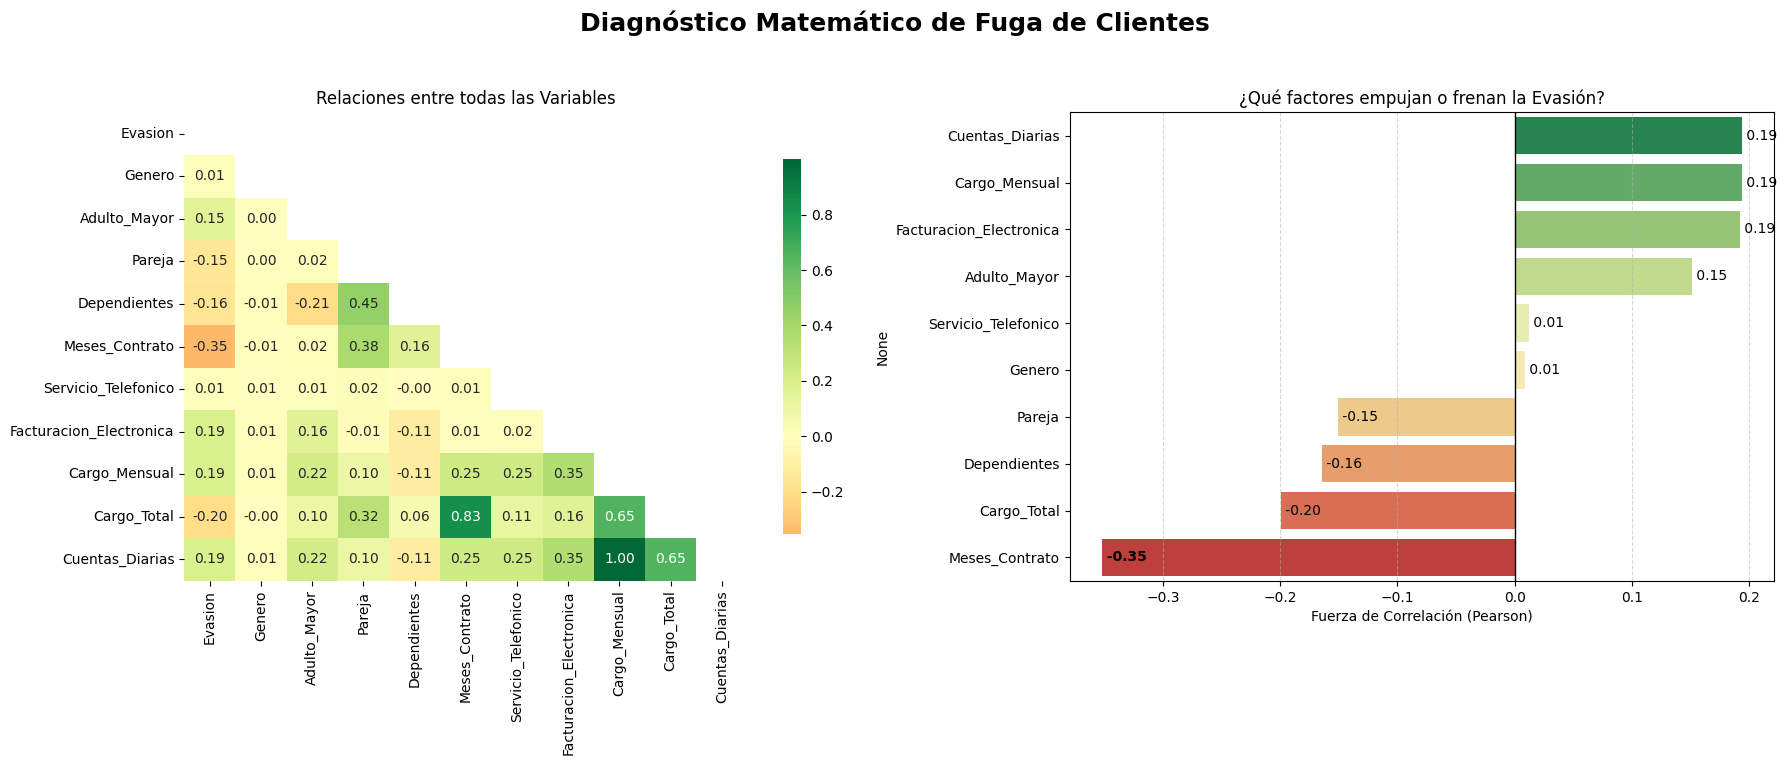

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# ANÁLISIS DE CORRELACIÓN: El Escáner de Responsabilidades
# ==============================================================================

# 1. Seleccionamos solo las columnas numéricas (incluyendo las nuevas hipótesis)
# Excluimos ID_Cliente porque es un texto identificador
df_corr = df.select_dtypes(include=[np.number])

# 2. Calculamos la matriz de Pearson
matriz = df_corr.corr()

# 3. Configuramos el lienzo para dos gráficos
fig, ejes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Diagnóstico Matemático de Fuga de Clientes', fontsize=18, fontweight='bold')

# ------------------------------------------------------------------------------
# GRÁFICO 1: Matriz Global (Heatmap)
# ------------------------------------------------------------------------------
# Usamos una máscara para ver solo la mitad inferior (evita duplicidad visual)
mask = np.triu(np.ones_like(matriz, dtype=bool))

sns.heatmap(matriz, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn',
            center=0, ax=ejes[0], cbar_kws={"shrink": .8})
ejes[0].set_title('Relaciones entre todas las Variables')

# ------------------------------------------------------------------------------
# GRÁFICO 2: Foco en la Evasión (El ranking de "Culpables")
# ------------------------------------------------------------------------------
# Extraemos solo la columna de Evasion y la ordenamos
fuga_rank = matriz['Evasion'].sort_values(ascending=False).drop('Evasion')

sns.barplot(x=fuga_rank.values, y=fuga_rank.index, palette='RdYlGn_r', ax=ejes[1], hue= fuga_rank.index,legend=False)
ejes[1].set_title('¿Qué factores empujan o frenan la Evasión?')
ejes[1].set_xlabel('Fuerza de Correlación (Pearson)')
ejes[1].axvline(x=0, color='black', linestyle='-', linewidth=1) # Línea de neutralidad
ejes[1].grid(axis='x', linestyle='--', alpha=0.5)

# Inyectamos los valores exactos para precisión analítica
for i, v in enumerate(fuga_rank.values):
    ejes[1].text(v, i, f' {v:.2f}', va='center', fontweight='bold' if abs(v) > 0.3 else 'normal')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 🛠️ Sección: Preparación y Exportación del Dataset para ML



En esta etapa de transición de la **Analítica Descriptiva** a la **Analítica Predictiva**, preparamos el terreno para los algoritmos de Machine Learning. Como estudiante de informática, sabemos que la calidad de la salida (*output*) depende estrictamente de la calidad de la entrada (*input*).

### 🧠 Selección de Características (Feature Selection)
Para optimizar el rendimiento de los modelos y evitar el sobreajuste (*overfitting*), aplicamos los siguientes criterios de ingeniería:

* **Eliminación de Identificadores:** Se remueve `ID_Cliente` dado que es una etiqueta única sin valor estadístico que solo añadiría ruido al aprendizaje del modelo.
* **Reducción de Multicolinealidad:** Tras detectar una correlación de **1.00** entre `Cuentas_Diarias` y `Cargo_Mensual`, eliminamos la primera. Mantener ambas variables "espejo" sesgaría el peso del costo mensual en el algoritmo.
* **Limpieza de Ruido Estadístico:** Variables como `Genero` y `Servicio_Telefonico` (correlación ~0.01) son descartadas para simplificar el modelo, siguiendo el principio de parsimonia.

### 🚿 Tratamiento Final de Nulos e Integridad
Durante la auditoría técnica, se identificó que la variable `Cargo_Total` ocultaba valores en blanco (`" "`) correspondientes a clientes recién adquiridos (antigüedad de 0 meses), lo que forzaba a la columna a comportarse como texto.
* **Acción Correctiva:** Se transformó la columna a formato numérico estricto y se aplicó una imputación lógica de **0.0** a dichos registros. Esto asegura la integridad matemática de la variable, dejándola lista para la fase de escalado y modelado.

---

### 💻 Implementación de Limpieza Final
El siguiente bloque de código ejecuta la poda final del dataset y genera el archivo comprimido listo para el entrenamiento de la IA.

In [24]:
# ==============================================================================
# PREPARACIÓN FINAL DEL DATASET (Fin de Exploración -> Inicio Pre-ML)
# ==============================================================================

# 1. Feature Selection: Definimos las columnas a descartar por ruido o multicolinealidad
columnas_a_quitar = [
    'ID_Cliente',           # Identificador único (causa overfitting).
    'Genero',               # Bajo impacto predictivo (ruido).
    'Servicio_Telefonico',  # Bajo impacto predictivo (ruido).
    'Cuentas_Diarias',      # Multicolinealidad perfecta con Cargo_Mensual.
    'Cargo_Total'           # Multicolinealidad con Cargo_Mensual y Meses_Contrato.
]

# Creamos una copia limpia descartando las variables no deseadas
df_ml = df.drop(columns=columnas_a_quitar).copy()

# 2. Verificación de integridad final
print(f"✅ Proceso de selección de características completado.")
print(f"   - Columnas originales en EDA: {df.shape[1]}")
print(f"   - Columnas finales conservadas: {df_ml.shape[1]}")

# 3. EXPORTACIÓN DEL DATASET
# Guardamos el archivo base. El preprocesamiento (One-Hot, Escalado) se hará en ML.
ruta_exportacion = '/content/dataset_telecom_ML.csv'
df_ml.to_csv(ruta_exportacion, index=False)

print(f"\n🚀 El dataset ha sido exportado exitosamente como '{ruta_exportacion}'")
display(df_ml.head(3))

✅ Proceso de selección de características completado.
   - Columnas originales en EDA: 24
   - Columnas finales conservadas: 19

🚀 El dataset ha sido exportado exitosamente como '/content/dataset_telecom_ML.csv'


,Evasion,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargo_Mensual,Puntaje_Inseguro,Total_Servicios
0,0,0,1,1,9,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,2.0,4.0
1,0,0,0,0,9,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,4.0,2.0
2,1,0,0,0,4,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,3.0,2.0


# Challenge Telecom X Parte II

In [1]:
import pandas as pd
import seaborn as sns

# ==============================================================================
# IMPORTACIÓN DEL DATASET
# ==============================================================================

ruta_original = 'https://github.com/MiyoBran/alura-etl-telecom-x-parte-II/blob/main/datos_tratados.csv'
ruta_original = ruta_original.replace('/github.com' , '/raw.githubusercontent.com')
ruta_original = ruta_original.replace('/blob' , '')
df = pd.read_csv(ruta_original)

# Nuestro Dataset "Original"
display(df.head())

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Puntaje_Inseguro,Total_Servicios
0,0002-ORFBO,0,1,0,1,1,9,1,0,DSL,...,1,0,One year,1,Mailed check,65.6,593.30,2.19,2.0,4.0
1,0003-MKNFE,0,0,0,0,0,9,1,1,DSL,...,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00,4.0,2.0
2,0004-TLHLJ,1,0,0,0,0,4,1,0,Fiber optic,...,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46,3.0,2.0
3,0011-IGKFF,1,0,1,1,0,13,1,0,Fiber optic,...,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27,2.0,5.0
4,0013-EXCHZ,1,1,1,1,0,3,1,0,Fiber optic,...,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80,3.0,3.0


In [2]:
# El Dataset Nuevo , cargado desde url en este punto si se decide obviar todo lo
# anterior, tratado con nuestras modificaciones
ruta_dataset = 'https://github.com/MiyoBran/alura-etl-telecom-x-parte-II/blob/main/dataset_telecom_ML.csv'
ruta_dataset = ruta_dataset.replace('/blob' , '').replace('/github.com' , '/raw.githubusercontent.com')
df_ml = pd.read_csv(ruta_dataset)
df_ml.head()

,Evasion,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargo_Mensual,Puntaje_Inseguro,Total_Servicios
0,0,0,1,1,9,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,2.0,4.0
1,0,0,0,0,9,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,4.0,2.0
2,1,0,0,0,4,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,3.0,2.0
3,1,1,1,0,13,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,2.0,5.0
4,1,1,1,0,3,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,3.0,3.0


## Preparando el dataset

In [17]:
# Asumimos importado pandas as pd y seaborn as sns
# También requerimos importar matplotlib para un control fino de la arquitectura visual
import matplotlib.pyplot as plt

def auditar_distribucion_y_relaciones(df: pd.DataFrame, col_target: str, cols_predictores: list[str]) -> None:
    """
    Ejecuta una auditoría visual de la variable dependiente (Y) y sus predictores (X).
    Evalúa estadísticamente la asimetría poblacional y la varianza (Homocedasticidad vs Heterocedasticidad).
    """
    # 1. Configuración global de estilo (Se define una sola vez para mantener coherencia visual)
    sns.set_palette("Accent")
    sns.set_style("darkgrid")

    # ---------------------------------------------------------------------
    # DIAGNÓSTICO 1: Distribución del Target (Auditoría de Asimetría)
    # ---------------------------------------------------------------------
    # Utilizamos subplots para consolidar el Boxplot y el Histograma en una sola figura limpia
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    fig.suptitle('Auditoría del Target (Y): Análisis de Asimetría en USD', fontsize=20, y=1.05)

    # Boxplot: Permite visualizar los outliers (valores atípicos) que "estiran" la media poblacional
    sns.boxplot(data=df, x=col_target, ax=axes[0], width=0.3)
    axes[0].set_title('Boxplot: Concentración Intercuartílica')
    axes[0].set_xlabel('Valor (USD)')

    # Histograma + KDE: Visualiza la Asimetría Positiva (Cola larga hacia la derecha)
    sns.histplot(data=df, x=col_target, kde=True, ax=axes[1])
    axes[1].set_title('Histograma: Distribución de Frecuencias')
    axes[1].set_xlabel('Valor (USD)')

    plt.show()

    # ---------------------------------------------------------------------
    # DIAGNÓSTICO 2: Dispersión y Varianza (Auditoría de Heterocedasticidad)
    # ---------------------------------------------------------------------
    # Pairplot con línea de regresión (kind='reg').
    # Buscamos observar si el error es constante (Homocedasticidad) o si forma un cono (Heterocedasticidad).
    grafico_relaciones = sns.pairplot(
        data=df,
        y_vars=col_target,
        x_vars=cols_predictores,
        kind='reg',
        height=5
    )
    grafico_relaciones.fig.suptitle('Relación Lineal: Predictores (X) vs Target (Y)', fontsize=20, y=1.05)
    plt.show()

# Ejecución de la función con variables claramente definidas
# Supongamos que tu DataFrame ya fue cargado previamente como 'df_propiedades'
variables_predictoras = ['Area', 'Dist_Playa', 'Dist_Farmacia']
auditar_distribucion_y_relaciones(df_propiedades, col_target='Valor', cols_predictores=variables_predictoras)

NameError: name 'df_propiedades' is not defined